# Trabajo Práctico N° 4 - Métodos de Regularización y CART para Predicción de Pobreza
## Universidad de Buenos Aires - Facultad de Ciencias Económicas
## Taller de Programación - Grupo 10

---

### Objetivo

El presente trabajo práctico tiene como objetivo aplicar técnicas de **machine learning supervisado** para predecir si una persona es pobre utilizando características socioeconómicas y demográficas individuales provenientes de la Encuesta Permanente de Hogares (EPH) del INDEC.

Se implementarán y compararán dos modelos de regularización de los coeficientes obtenidos por regresión:
- **Ridge**: aplica penalidad no estricta.
- **LASSO**: aplica penalidad estricta, selecciona predictores.

Se compararán los resultados obtenidos con la predicción por CART:
- **Árboles de decisión**: método no paramétrico de función de densidad condicional. 

### Estructura del análisis

**A. Modelo de Regresion Logistica con Regularización: Ridge y LASSO:** visualización de la grilla de coeficientes y selección de penalidad lambda por cross validation. 

**B. Árboles de decisión:** Estimación, interpretación de coeficientes y visualización.

**C. Comparación entre métodos:** performance predictiva, interpretabilidad de los resultados y aplicación de políticas públicas.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from estilo_graficos import UBA_FCE_COLORS, configurar_estilo_grafico, formatear_ejes, forzar_y_cero

COLORES = configurar_estilo_grafico(dpi=120, base_fontsize=10, variante="claro")

## A. Modelo de Regresion Logistica con Regularización

Se trabaja con datos de la EPH 2025 del Gran Buenos Aires, utilizando la base de trabajo generada en el TP previo.

**Estrategia de validación replicada del TP3:**
- División train/test: 70% entrenamiento - 30% prueba
- Estratificación por variable objetivo (POBRE) para mantener proporción de pobres en ambos conjuntos
- Random state = 444 para reproducibilidad (según consigna del TP)

**Variables predictoras seleccionadas:**
- `CH04`: Sexo (1=Varón, 2=Mujer)
- `CH06`: Edad en años cumplidos
- `NIVEL_ED`: Nivel educativo alcanzado
- `ESTADO`: Condición de actividad (Ocupado/Desocupado/Inactivo)
- `HORASTRAB`: Horas trabajadas por semana
- `CAT_OCUP`: Categoría ocupacional

In [16]:
# Cargar base de trabajo procesada (contiene solo 2025)
df_trabajo= pd.read_csv("../TP3/datos/base_tp3_trabajo.csv")            
        
display(df_trabajo.head())

,CH06,HORASTRAB,POBRE,CH04_2,NIVEL_ED_2,NIVEL_ED_3,NIVEL_ED_4,NIVEL_ED_5,NIVEL_ED_6,NIVEL_ED_7,ESTADO_2,ESTADO_3,ESTADO_4,CAT_OCUP_1.0,CAT_OCUP_2.0,CAT_OCUP_3.0,CAT_OCUP_4.0,CAT_OCUP_9.0
0,30.0,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,82.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,34.0,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,32.0,0.0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,10.0,0.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [20]:
# Renombrar Ch04_2 a Sexo y CH06 a Edad para simplificar visualización de las etiquetas
df_trabajo = df_trabajo.rename(columns={'CH04_2': 'Sexo', 'CH06': 'Edad'})

In [21]:
# Réplica de la división train/test del TP3

X = df_trabajo.drop('POBRE', axis=1)
y = df_trabajo['POBRE']

# División train/test según consigna: 70% train, 30% test, random_state=444, estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=444, stratify=y)

print(f"\n{'='*70}")
print(f"DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)")
print(f"{'='*70}")
print(f"Train: {len(X_train):,} obs ({len(X_train)/len(X)*100:.1f}%) - Pobres: {y_train.mean()*100:.1f}%")
print(f"Test:  {len(X_test):,} obs ({len(X_test)/len(X)*100:.1f}%) - Pobres: {y_test.mean()*100:.1f}%")
print(f"Total features: {X_train.shape[1]}")


DIVISIÓN TRAIN/TEST SEGÚN CONSIGNA (70-30, random_state=444)
Train: 3,023 obs (70.0%) - Pobres: 31.5%
Test:  1,296 obs (30.0%) - Pobres: 31.4%
Total features: 17


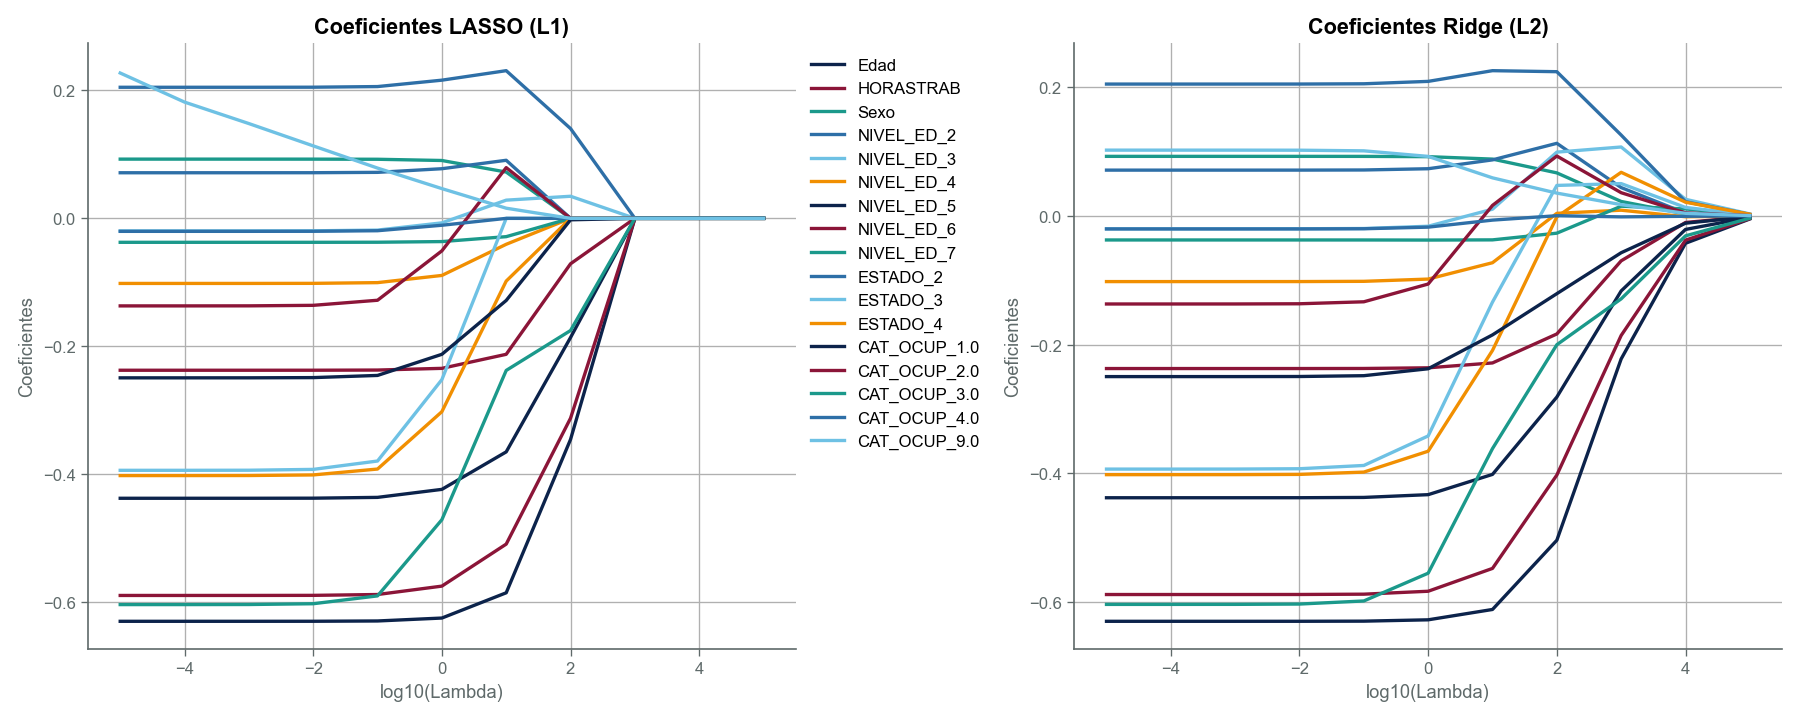

In [22]:
# Preparar los datos:
# Estandarizar (para posterior Regularización)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Definir la grilla de Lambda y C
# La consigna pide lambda = 10^n. Suponemos n entre -5 y 5
n_values = range(-5, 6)
lambdas = [10**n for n in n_values]
Cs = [1/l for l in lambdas] # Scikit-learn usa C, que es 1/lambda

# Entrenar modelos y guardar coeficientes
coefs_lasso = []
coefs_ridge = []

for c in Cs:
    # LASSO (Penalty L1)
    # solver='liblinear' funciona bien para datasets pequeños/medianos con L1
    lasso = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    lasso.fit(X_std, y)
    coefs_lasso.append(lasso.coef_[0])
    
    # RIDGE (Penalty L2)
    ridge = LogisticRegression(penalty='l2', C=c, solver='lbfgs', random_state=42)
    ridge.fit(X_std, y)
    coefs_ridge.append(ridge.coef_[0])

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico LASSO
ax[0].plot(np.log10(lambdas), coefs_lasso)
ax[0].set_xlabel('log10(Lambda)')
ax[0].set_ylabel('Coeficientes')
ax[0].set_title('Coeficientes LASSO (L1)')
ax[0].legend(X.columns, bbox_to_anchor=(1, 1))
ax[0].grid(True)

# Gráfico Ridge
ax[1].plot(np.log10(lambdas), coefs_ridge)
ax[1].set_xlabel('log10(Lambda)')
ax[1].set_ylabel('Coeficientes')
ax[1].set_title('Coeficientes Ridge (L2)')
ax[1].grid(True)

plt.tight_layout()
plt.show()

**Interpretación del Gráfico LASSO (Izquierda)**

Lo más distintivo de LASSO (penalidad L1) es su capacidad de Selección de Variables.
El efecto "Cero Exacto": Observa cómo las líneas de colores no solo se achican, sino que golpean el 0 y se quedan ahí. Matemáticamente, LASSO fuerza a que los coeficientes de las variables menos importantes sean exactamente cero.

A medida que aumenta $\lambda$ (hacia la derecha), el modelo empieza a "apagar" variables. Las líneas que caen a cero rápidamente (en $\lambda$ bajos) corresponden a variables que no aportan mucha información para predecir pobreza o que son redundantes.

Las líneas que "sobreviven" más tiempo (se mantienen distintas de cero hacia la derecha) son los predictores más fuertes.

Conclusión: LASSO entrega un modelo más simple eliminando ruido.

**Interpretación del Gráfico Ridge (Derecha)**

Ridge (penalidad L2) funciona distinto; su propiedad principal es la contracción suave.

El efecto Asintótico: las líneas se curvan suavemente hacia el 0, pero nunca lo tocan realmente (o tardan muchísimo más).

Ridge nunca elimina variables. Incluso con penalizaciones altas, sigue usando toda la información disponible, solo que reduce la magnitud de los coeficientes para evitar que una sola variable domine excesivamente.

Esto es útil para reducir la varianza sin perder información, pero no simplifica la interpretación del modelo.

**Conclusión**

En el gráfico de LASSO, observamos que a medida que aumenta el parámetro de penalización $\lambda$, los coeficientes de varias variables se reducen exactamente a cero. 

Esto confirma la propiedad de selección de variables de la regularización L1, donde el modelo descarta predictores menos relevantes, generando una solución simplificada.

Por el contrario, en el gráfico de Ridge, los coeficientes convergen asintóticamente a cero pero no se anulan. La penalización L2 reduce la magnitud de los coeficientes (shrinkage) para controlar la varianza y la multicolinealidad, pero mantiene todas las variables en el modelo final.